In [1]:
import typing as t

import polars as pl

from src.config.constants import Product
from src.research import (
    AnalysisResult,
    OrderbookAnalysisResult,
    Plots,
    TradesAnalysisResult,
    run_analysis,
    display_plots,
)

TOMATOES: t.Final[Product] = Product.TOMATOES
ROUND: t.Final[int] = 0
DAY: t.Final[int] = -1

analysis_result: t.Final[AnalysisResult] = run_analysis(ROUND, DAY, TOMATOES)
orderbook_analysis: t.Final[OrderbookAnalysisResult] = (
    analysis_result.orderbook_analysis_result
)
trades_analysis: t.Final[TradesAnalysisResult] = analysis_result.trades_analysis_result

# Orderbook Analysis

In [2]:
orderbook_data: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_data
orderbook_features_data: t.Final[pl.DataFrame] = (
    orderbook_analysis.orderbook_features_data
)
orderbook_stats: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_stats
orderbook_corrs: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_corrs

orderbook_data

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,i64
0,4999,5,4998,15,null,null,5013,5,5014,15,null,null,5006.0,14,0.0,null,0.0001,5006.0,0.0,10
100,5000,8,4998,21,null,null,5013,8,5014,21,null,null,5006.5,13,0.0,0.0001,0.0,5006.5,0.0,16
200,5000,10,4999,20,null,null,5013,10,5015,20,null,null,5006.5,13,0.0,0.0,0.0001,5006.5,0.0,20
300,5000,9,4999,21,null,null,5014,9,5015,21,null,null,5007.0,14,0.0,0.0001,0.0,5007.0,0.0,18
400,5000,5,4999,20,null,null,5014,5,5015,20,null,null,5007.0,14,0.0,0.0,0.0,5007.0,0.0,10
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,4955,5,4950,10,4948,23,4963,10,4964,23,null,null,4959.0,8,0.070423,0.000605,0.0,4957.666667,-1.333333,15
999600,4955,5,4949,6,4948,18,4963,6,4964,18,null,null,4959.0,8,0.09434,0.0,-0.000504,4958.636364,-0.363636,11
999700,4950,10,4948,16,null,null,4963,10,4964,16,null,null,4956.5,13,0.0,-0.000504,0.000202,4956.5,0.0,20


In [3]:
orderbook_features_data

timestamp,mid_price,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,f64,i64,f64,f64,f64,f64,f64,i64
0,5006.0,14,0.0,null,0.0001,5006.0,0.0,10
100,5006.5,13,0.0,0.0001,0.0,5006.5,0.0,16
200,5006.5,13,0.0,0.0,0.0001,5006.5,0.0,20
300,5007.0,14,0.0,0.0001,0.0,5007.0,0.0,18
400,5007.0,14,0.0,0.0,0.0,5007.0,0.0,10
…,…,…,…,…,…,…,…,…
999500,4959.0,8,0.070423,0.000605,0.0,4957.666667,-1.333333,15
999600,4959.0,8,0.09434,0.0,-0.000504,4958.636364,-0.363636,11
999700,4956.5,13,0.0,-0.000504,0.000202,4956.5,0.0,20


In [4]:
orderbook_stats

mid_mean,mid_var,mid_std,micro_mean,micro_var,micro_std,ret_mean,ret_var,ret_std
f64,f64,f64,f64,f64,f64,f64,f64,f64
4977.56775,212.532588,14.578497,4977.562109,212.248573,14.568753,-9.8375e-7,7.2164e-8,0.000269


In [5]:
orderbook_corrs

imb_corr,micro_corr
f64,f64
-0.580231,0.331009


# Trades Analysis

In [6]:
trades_data: t.Final[pl.DataFrame] = trades_analysis.trades_data
time_interval_stats: t.Final[pl.DataFrame] = trades_analysis.time_interval_stats
quantities_stats: t.Final[pl.DataFrame] = trades_analysis.quantities_stats
order_side_stats: t.Final[pl.DataFrame] = trades_analysis.order_side_stats
trade_price_streaks_stats: t.Final[pl.DataFrame] = (
    trades_analysis.trade_price_streaks_stats
)
trades_plots: t.Final[Plots] = trades_analysis.plots

trades_data

timestamp,price,quantity,best_bid,best_ask,mid_price,time_since_prev_trade,time_until_next_trade,mid_price_dev,side_heur
i64,f64,i64,i64,i64,f64,i64,i64,f64,str
3400,5009.0,2,4996,5009,5002.5,null,3600,6.5,"""BUY_ORDER"""
7000,5010.0,4,4997,5010,5003.5,3600,2600,6.5,"""BUY_ORDER"""
9600,4999.0,5,4999,5013,5006.0,2600,300,-7.0,"""SELL_ORDER"""
9900,5000.0,4,5000,5013,5006.5,300,6500,-6.5,"""SELL_ORDER"""
16400,4996.0,2,4996,5010,5003.0,6500,1500,-7.0,"""SELL_ORDER"""
…,…,…,…,…,…,…,…,…,…
979000,4965.0,5,4952,4965,4958.5,1100,3500,6.5,"""BUY_ORDER"""
982500,4950.0,3,4950,4964,4957.0,3500,2600,-7.0,"""SELL_ORDER"""
985100,4946.0,2,4946,4960,4953.0,2600,7900,-7.0,"""SELL_ORDER"""


In [7]:
time_interval_stats

time_since_prev_mean,time_since_prev_var,time_since_prev_std,time_until_next_mean,time_until_next_var,time_until_next_std
f64,f64,f64,f64,f64,f64
2351.184834,5.4638e6,2337.484695,2351.184834,5.4638e6,2337.484695


In [8]:
quantities_stats

qty_mean,qty_median,qty_mode,qty_var,qty_std
f64,f64,i64,f64,f64
3.408983,3.0,3,1.218592,1.103899


In [9]:
order_side_stats

total_orders,buy_orders,buy_order_rate,sell_orders,sell_order_rate
i64,i64,f64,i64,f64
423,198,0.468085,225,0.531915


In [10]:
trade_price_streaks_stats

price,streak_length
f64,u32
4958.0,1
4982.0,1
4955.0,1
4966.0,1
4984.0,1
…,…
4976.0,1
4993.0,1
4985.0,1


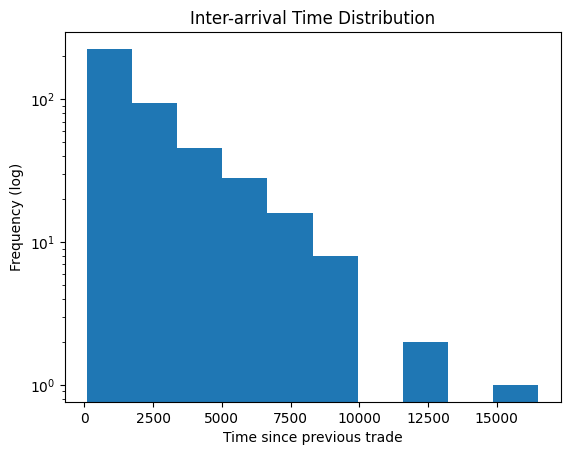

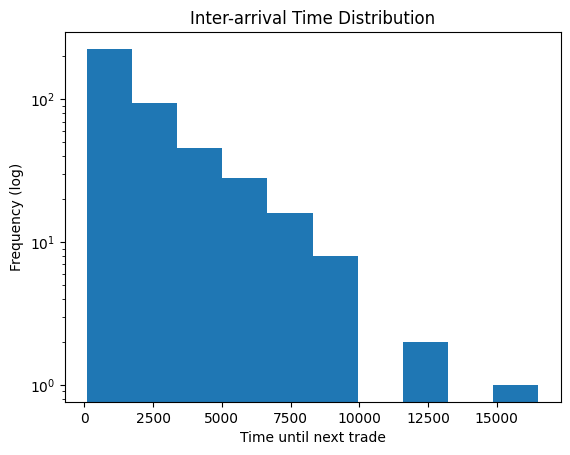

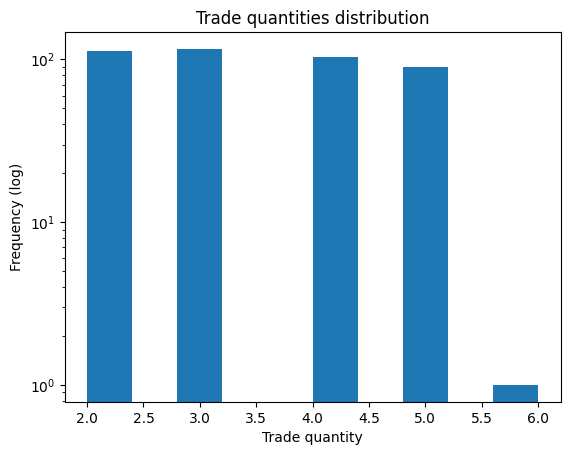

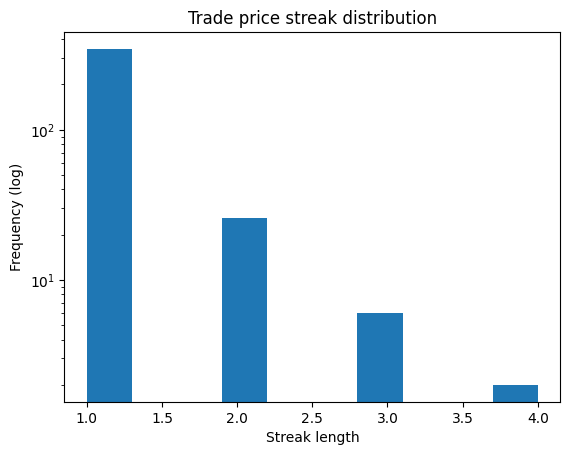

In [11]:
display_plots(trades_plots)